# Model Comparison — Model 1 vs Model 2

Compares every measurable dimension of the two architectures:

1. **Training dynamics** — loss curves side by side
2. **BLEU scores** — all n-gram levels, all decoding strategies
3. **Ablation breakdown** — encoder swap vs beam search, isolated
4. **Qualitative comparison** — same test images captioned by both models
5. **Error analysis** — where each model wins and loses


## 1. Setup

In [1]:
import math
import pickle
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights, vit_b_16, ViT_B_16_Weights
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PROJECT_ROOT   = Path("..").resolve()
PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"


Device: cuda


## 2. Load shared artefacts & saved results

In [2]:
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]
    def __init__(self):
        self.word2idx = {}; self.idx2word = {}
        for tok in self.SPECIAL_TOKENS: self._add(tok)
    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx); self.word2idx[word] = i; self.idx2word[i] = word
    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions: counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq: vocab._add(word)
        vocab.freq = counter; return vocab
    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]
    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special: ids = [self.start_idx] + ids + [self.end_idx]
        return ids
    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)
    def __len__(self): return len(self.word2idx)


In [3]:
with open(PROCESSED_DIR / "vocab.pkl",      "rb") as f: vocab      = pickle.load(f)
with open(PROCESSED_DIR / "test_data.pkl",  "rb") as f: test_data  = pickle.load(f)
with open(PROCESSED_DIR / "config.pkl",     "rb") as f: config     = pickle.load(f)

PAD_IDX = vocab.pad_idx; SOS_IDX = vocab.start_idx
EOS_IDX = vocab.end_idx; UNK_IDX = vocab.unk_idx
VOCAB_SIZE = len(vocab)
print(f"vocab_size={VOCAB_SIZE}  test_images={len(test_data)}")


vocab_size=3214  test_images=1132


In [4]:
with open(CHECKPOINT_DIR / "model1_transformer_results.pkl", "rb") as f:
    r1 = pickle.load(f)
with open(CHECKPOINT_DIR / "model2_vit_transformer_results.pkl", "rb") as f:
    r2 = pickle.load(f)

print("Model 1 keys:", list(r1.keys()))
print("Model 2 keys:", list(r2.keys()))


Model 1 keys: ['model_name', 'encoder', 'decoder', 'attention', 'd_model', 'num_decoder_layers', 'nhead', 'dim_feedforward', 'dropout', 'label_smoothing', 'epochs', 'warmup_epochs', 'peak_lr', 'weight_decay', 'best_val_loss', 'trainable_params', 'history', 'val_bleu', 'test_bleu']
Model 2 keys: ['model_name', 'encoder', 'decoder', 'attention', 'decoding', 'd_model', 'num_decoder_layers', 'nhead', 'dim_feedforward', 'dropout', 'label_smoothing', 'epochs', 'warmup_epochs', 'peak_lr', 'weight_decay', 'best_val_loss', 'trainable_params', 'history', 'val_bleu_greedy', 'val_bleu_beam', 'test_bleu_greedy', 'test_bleu_beam']


## 3. Training dynamics

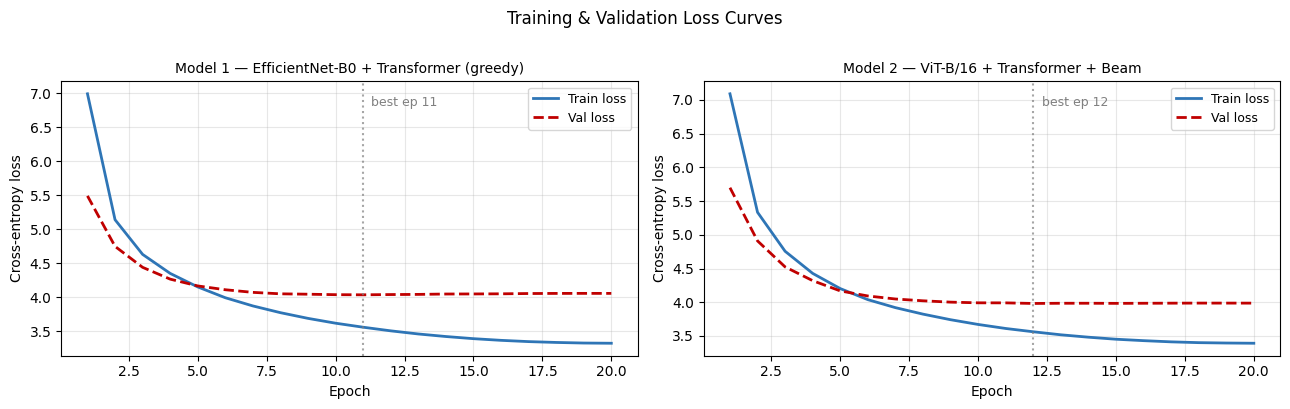

Model 1 — best val loss: 4.0374
Model 2 — best val loss: 3.9819


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
COLORS = {"train": "#2E75B6", "val": "#C00000"}

for ax, r, title in zip(axes, [r1, r2], ["Model 1 — EfficientNet-B0 + Transformer (greedy)",
                                          "Model 2 — ViT-B/16 + Transformer + Beam"]):
    epochs = range(1, len(r["history"]["train_loss"]) + 1)
    ax.plot(epochs, r["history"]["train_loss"], color=COLORS["train"],  lw=2, label="Train loss")
    ax.plot(epochs, r["history"]["val_loss"],   color=COLORS["val"],    lw=2, label="Val loss",
            linestyle="--")
    best_ep = r["history"]["val_loss"].index(min(r["history"]["val_loss"])) + 1
    ax.axvline(best_ep, color="grey", linestyle=":", alpha=0.7)
    ax.text(best_ep + 0.3, ax.get_ylim()[1] * 0.97,
            f"best ep {best_ep}", fontsize=9, color="grey", va="top")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy loss")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Training & Validation Loss Curves", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"Model 1 — best val loss: {min(r1['history']['val_loss']):.4f}")
print(f"Model 2 — best val loss: {min(r2['history']['val_loss']):.4f}")


## 4. BLEU score comparison

In [6]:
# Collect all scores into a tidy DataFrame
records = [
    {"Model": "M1: EfficientNet + Transformer", "Decoding": "Greedy", "Split": "Val",
     **{f"BLEU-{i}": r1["val_bleu"][f"BLEU-{i}"] for i in range(1,5)}},
    {"Model": "M1: EfficientNet + Transformer", "Decoding": "Greedy", "Split": "Test",
     **{f"BLEU-{i}": r1["test_bleu"][f"BLEU-{i}"] for i in range(1,5)}},
    {"Model": "M2: ViT-B/16 + Transformer",     "Decoding": "Greedy", "Split": "Val",
     **{f"BLEU-{i}": r2["val_bleu_greedy"][f"BLEU-{i}"] for i in range(1,5)}},
    {"Model": "M2: ViT-B/16 + Transformer",     "Decoding": "Greedy", "Split": "Test",
     **{f"BLEU-{i}": r2["test_bleu_greedy"][f"BLEU-{i}"] for i in range(1,5)}},
    {"Model": "M2: ViT-B/16 + Transformer",     "Decoding": "Beam k=3", "Split": "Val",
     **{f"BLEU-{i}": r2["val_bleu_beam"][f"BLEU-{i}"] for i in range(1,5)}},
    {"Model": "M2: ViT-B/16 + Transformer",     "Decoding": "Beam k=3", "Split": "Test",
     **{f"BLEU-{i}": r2["test_bleu_beam"][f"BLEU-{i}"] for i in range(1,5)}},
]
df = pd.DataFrame(records)
test_df = df[df["Split"] == "Test"].reset_index(drop=True)
print(test_df[["Model","Decoding","BLEU-1","BLEU-2","BLEU-3","BLEU-4"]].to_string(index=False))


                         Model Decoding   BLEU-1   BLEU-2   BLEU-3   BLEU-4
M1: EfficientNet + Transformer   Greedy 0.555213 0.354358 0.220654 0.136056
    M2: ViT-B/16 + Transformer   Greedy 0.571502 0.378582 0.241526 0.150463
    M2: ViT-B/16 + Transformer Beam k=3 0.609366 0.416757 0.279431 0.185695


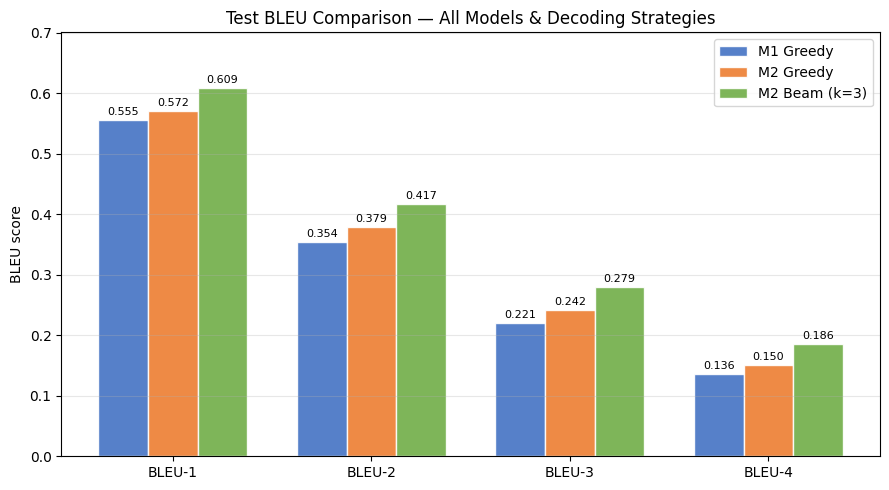

In [7]:
# Grouped bar chart — test BLEU-1 through BLEU-4
labels = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
rows = [
    ("M1 Greedy",       [r1["test_bleu"][f"BLEU-{i}"] for i in range(1,5)],    "#4472C4"),
    ("M2 Greedy",       [r2["test_bleu_greedy"][f"BLEU-{i}"] for i in range(1,5)], "#ED7D31"),
    ("M2 Beam (k=3)",   [r2["test_bleu_beam"][f"BLEU-{i}"] for i in range(1,5)],   "#70AD47"),
]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))

for idx, (name, vals, color) in enumerate(rows):
    bars = ax.bar(x + (idx - 1) * width, vals, width, label=name,
                  color=color, alpha=0.9, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("BLEU score"); ax.set_title("Test BLEU Comparison — All Models & Decoding Strategies")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, max(r2["test_bleu_beam"]["BLEU-1"]*1.15, 0.7))
plt.tight_layout(); plt.show()


## 5. Ablation breakdown

In [8]:
# Isolate the two upgrades
m1_greedy  = r1["test_bleu"]["BLEU-4"]
m2_greedy  = r2["test_bleu_greedy"]["BLEU-4"]
m2_beam    = r2["test_bleu_beam"]["BLEU-4"]

encoder_gain  = m2_greedy - m1_greedy
beam_gain     = m2_beam   - m2_greedy
combined_gain = m2_beam   - m1_greedy

ablation = pd.DataFrame({
    "Upgrade":      ["Encoder: EfficientNet → ViT (greedy held constant)",
                     "Decoding: Greedy → Beam k=3 (ViT held constant)",
                     "Combined (M1 greedy → M2 beam)"],
    "From BLEU-4":  [f"{m1_greedy:.4f}", f"{m2_greedy:.4f}", f"{m1_greedy:.4f}"],
    "To BLEU-4":    [f"{m2_greedy:.4f}", f"{m2_beam:.4f}",   f"{m2_beam:.4f}"],
    "Δ BLEU-4":     [f"+{encoder_gain:.4f}", f"+{beam_gain:.4f}", f"+{combined_gain:.4f}"],
    "Relative gain":[f"+{encoder_gain/m1_greedy*100:.1f}%",
                     f"+{beam_gain/m2_greedy*100:.1f}%",
                     f"+{combined_gain/m1_greedy*100:.1f}%"],
})
print("Ablation — BLEU-4 contributions:")
print(ablation.to_string(index=False))


Ablation — BLEU-4 contributions:
                                           Upgrade From BLEU-4 To BLEU-4 Δ BLEU-4 Relative gain
Encoder: EfficientNet → ViT (greedy held constant)      0.1361    0.1505  +0.0144        +10.6%
   Decoding: Greedy → Beam k=3 (ViT held constant)      0.1505    0.1857  +0.0352        +23.4%
                    Combined (M1 greedy → M2 beam)      0.1361    0.1857  +0.0496        +36.5%


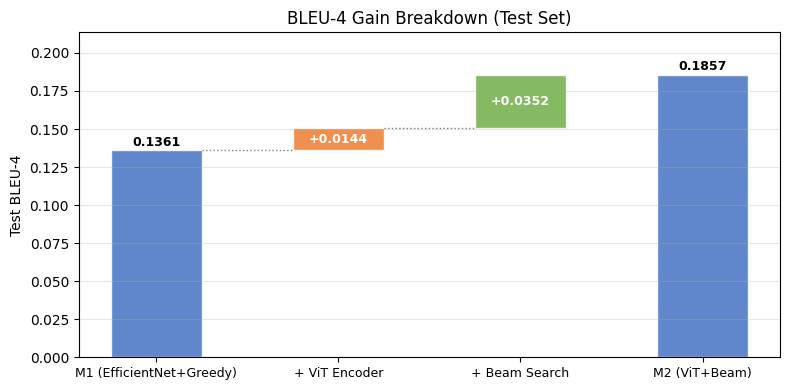

In [9]:
# Waterfall chart
fig, ax = plt.subplots(figsize=(8, 4))
stages = ["M1 (EfficientNet+Greedy)", "+ ViT Encoder", "+ Beam Search", "M2 (ViT+Beam)"]
bottoms = [0, m1_greedy, m2_greedy, 0]
heights = [m1_greedy, encoder_gain, beam_gain, m2_beam]
colors  = ["#4472C4", "#ED7D31", "#70AD47", "#4472C4"]
bar_types = ["base", "gain", "gain", "base"]

for i, (s, b, h, c, bt) in enumerate(zip(stages, bottoms, heights, colors, bar_types)):
    if bt == "base":
        ax.bar(i, h, color=c, alpha=0.85, edgecolor="white", width=0.5)
        ax.text(i, h + 0.003, f"{h:.4f}", ha="center", fontsize=9, fontweight="bold")
    else:
        ax.bar(i, h, bottom=b, color=c, alpha=0.85, edgecolor="white", width=0.5)
        ax.text(i, b + h/2, f"+{h:.4f}", ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")
        ax.plot([i-0.75, i-0.25], [b, b], color="grey", lw=1, linestyle=":")

ax.set_xticks(range(4)); ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel("Test BLEU-4"); ax.set_title("BLEU-4 Gain Breakdown (Test Set)")
ax.set_ylim(0, m2_beam * 1.15); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Qualitative comparison

Load both model checkpoints and generate captions for the same test images side by side. We compare three categories: examples where both models agree, where Model 2 clearly improves, and where neither does well.

In [10]:
# ── Recreate both architectures for inference ────────────────────────────────

class EfficientNetEncoder(nn.Module):
    def __init__(self, d_model=256, dropout=0.1):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.projection = nn.Linear(1280, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        for p in self.features.parameters(): p.requires_grad = False
    def forward(self, images):
        with torch.no_grad():
            feats = self.features(images)
        B, C, H, W = feats.shape
        feats = feats.flatten(2).transpose(1, 2)
        return self.dropout(self.layer_norm(self.projection(feats)))


class ViTEncoder(nn.Module):
    def __init__(self, d_model=256, dropout=0.1):
        super().__init__()
        vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        self.conv_proj = vit.conv_proj; self.class_token = vit.class_token
        self.encoder = vit.encoder; self.hidden_dim = vit.hidden_dim
        for p in self.conv_proj.parameters(): p.requires_grad = False
        self.class_token.requires_grad = False
        for p in self.encoder.parameters(): p.requires_grad = False
        self.projection = nn.Linear(768, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def train(self, mode=True):
        super().train(mode); self.conv_proj.eval(); self.encoder.eval(); return self
    def forward(self, images):
        B = images.size(0)
        with torch.no_grad():
            x = self.conv_proj(images).flatten(2).transpose(1, 2)
            cls = self.class_token.expand(B, -1, -1)
            x = self.encoder(torch.cat([cls, x], dim=1))[:, 1:, :]
        return self.dropout(self.layer_norm(self.projection(x)))


class TransformerCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30, pad_idx=0):
        super().__init__()
        self.d_model = d_model; self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding   = nn.Embedding(max_len, d_model)
        self.embed_dropout   = nn.Dropout(dropout)
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, norm_first=True, activation="gelu")
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
    def _embed(self, captions):
        B, T = captions.shape
        pos = torch.arange(T, device=captions.device).unsqueeze(0).expand(B, T)
        return self.embed_dropout(
            self.token_embedding(captions) * math.sqrt(self.d_model) + self.pos_embedding(pos))
    def forward(self, memory, captions):
        T = captions.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(captions.device)
        tgt_kpm  = (captions == self.pad_idx)
        return self.fc_out(self.transformer(tgt=self._embed(captions), memory=memory,
                                             tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_kpm))
    @torch.no_grad()
    def generate_greedy(self, memory, start_idx, end_idx, max_len=25):
        B = memory.size(0); device = memory.device
        ys = torch.full((B, 1), start_idx, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)
        for _ in range(max_len):
            next_tok = self.forward(memory, ys)[:, -1, :].argmax(dim=-1)
            next_tok = torch.where(finished, torch.full_like(next_tok, self.pad_idx), next_tok)
            ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            finished = finished | (next_tok == end_idx)
            if finished.all(): break
        return ys
    @torch.no_grad()
    def generate_beam(self, memory, start_idx, end_idx, max_len=25, beam_size=3):
        B, S, _ = memory.shape; device = memory.device; results = []
        for b in range(B):
            mem = memory[b:b+1]; beams = [(0.0, [start_idx])]; finished = []
            for _ in range(max_len):
                candidates = []
                for lp_sum, toks in beams:
                    if toks[-1] == end_idx:
                        finished.append((lp_sum / max(1, len(toks)), toks)); continue
                    inp = torch.tensor([toks], device=device)
                    lp = F.log_softmax(self.forward(mem, inp)[0, -1, :], dim=-1)
                    for lp_v, tok in zip(*lp.topk(beam_size)):
                        candidates.append((lp_sum + lp_v.item(), toks + [tok.item()]))
                if not candidates: break
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = candidates[:beam_size]
            for lp_sum, toks in beams:
                finished.append((lp_sum / max(1, len(toks)), toks))
            best = max(finished, key=lambda x: x[0])[1]
            results.append(torch.tensor(best, device=device, dtype=torch.long))
        L = max(r.size(0) for r in results)
        out = torch.full((B, L), self.pad_idx, dtype=torch.long, device=device)
        for i, r in enumerate(results): out[i, :r.size(0)] = r
        return out


class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30,
                 pad_idx=0, start_idx=1, end_idx=2):
        super().__init__()
        self.encoder = encoder
        self.decoder = TransformerCaptionDecoder(vocab_size, d_model, nhead, num_layers,
                                                  dim_feedforward, dropout, max_len, pad_idx)
        self.start_idx = start_idx; self.end_idx = end_idx
    def forward(self, images, captions):
        return self.decoder(self.encoder(images), captions)
    @torch.no_grad()
    def generate(self, images, max_len=25, beam_size=1):
        self.eval()
        memory = self.encoder(images)
        if beam_size <= 1:
            return self.decoder.generate_greedy(memory, self.start_idx, self.end_idx, max_len)
        return self.decoder.generate_beam(memory, self.start_idx, self.end_idx, max_len, beam_size)


In [11]:
MAX_LEN = config["max_caption_length"] + 5

model1 = ImageCaptioningModel(
    EfficientNetEncoder(d_model=256), VOCAB_SIZE,
    pad_idx=PAD_IDX, start_idx=SOS_IDX, end_idx=EOS_IDX, max_len=MAX_LEN
).to(device)
ckpt1 = torch.load(CHECKPOINT_DIR / "model1_transformer_best.pt", map_location=device)
model1.load_state_dict(ckpt1["model"])
model1.eval()
print(f"Model 1 loaded (epoch {ckpt1['epoch']}, val_loss={ckpt1['val_loss']:.4f})")

model2 = ImageCaptioningModel(
    ViTEncoder(d_model=256), VOCAB_SIZE,
    pad_idx=PAD_IDX, start_idx=SOS_IDX, end_idx=EOS_IDX, max_len=MAX_LEN
).to(device)
ckpt2 = torch.load(CHECKPOINT_DIR / "model2_vit_transformer_best.pt", map_location=device)
model2.load_state_dict(ckpt2["model"])
model2.eval()
print(f"Model 2 loaded (epoch {ckpt2['epoch']}, val_loss={ckpt2['val_loss']:.4f})")


Model 1 loaded (epoch 11, val_loss=4.0374)
Model 2 loaded (epoch 12, val_loss=3.9819)


In [12]:
eval_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(config["imagenet_mean"], config["imagenet_std"]),
])
smoothie = SmoothingFunction().method1

def ids_to_tokens(ids):
    out = []
    for i in ids:
        w = vocab.idx2word.get(int(i), vocab.UNK)
        if w == vocab.END: break
        if w in (vocab.PAD, vocab.START): continue
        out.append(w)
    return out

@torch.no_grad()
def caption_image(path, model, beam_size=1):
    img = eval_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    ids = model.generate(img, max_len=25, beam_size=beam_size)[0].tolist()
    return " ".join(ids_to_tokens(ids))

def per_image_bleu(hyp_tokens, ref_token_lists):
    return sentence_bleu(ref_token_lists, hyp_tokens,
                         weights=(0.25,)*4, smoothing_function=smoothie)


In [13]:
# Pre-compute BLEU for every test image under each strategy
records = []
for item in tqdm(test_data, desc="test images"):
    path = item["image_path"]
    refs = [vocab.encode(c, add_special=False) for c in item["captions_tokens"]]
    ref_toks = [ids_to_tokens(r) for r in refs]

    cap_m1  = caption_image(path, model1, beam_size=1)
    cap_m2g = caption_image(path, model2, beam_size=1)
    cap_m2b = caption_image(path, model2, beam_size=3)

    records.append({
        "path":   path,
        "refs":   " | ".join([" ".join(t) for t in ref_toks[:2]]),
        "m1_cap": cap_m1,
        "m2g_cap":cap_m2g,
        "m2b_cap":cap_m2b,
        "m1_bleu4":  per_image_bleu(cap_m1.split(),   ref_toks),
        "m2g_bleu4": per_image_bleu(cap_m2g.split(),  ref_toks),
        "m2b_bleu4": per_image_bleu(cap_m2b.split(),  ref_toks),
    })

scored = pd.DataFrame(records)
scored["m2b_vs_m1"] = scored["m2b_bleu4"] - scored["m1_bleu4"]
print(f"Scored {len(scored)} test images")


test images:   0%|          | 0/1132 [00:00<?, ?it/s]

/home/billionaire-bros/setup/venv/lib/python3.12/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Scored 1132 test images


### 6a. Side-by-side: random sample of 6 test images

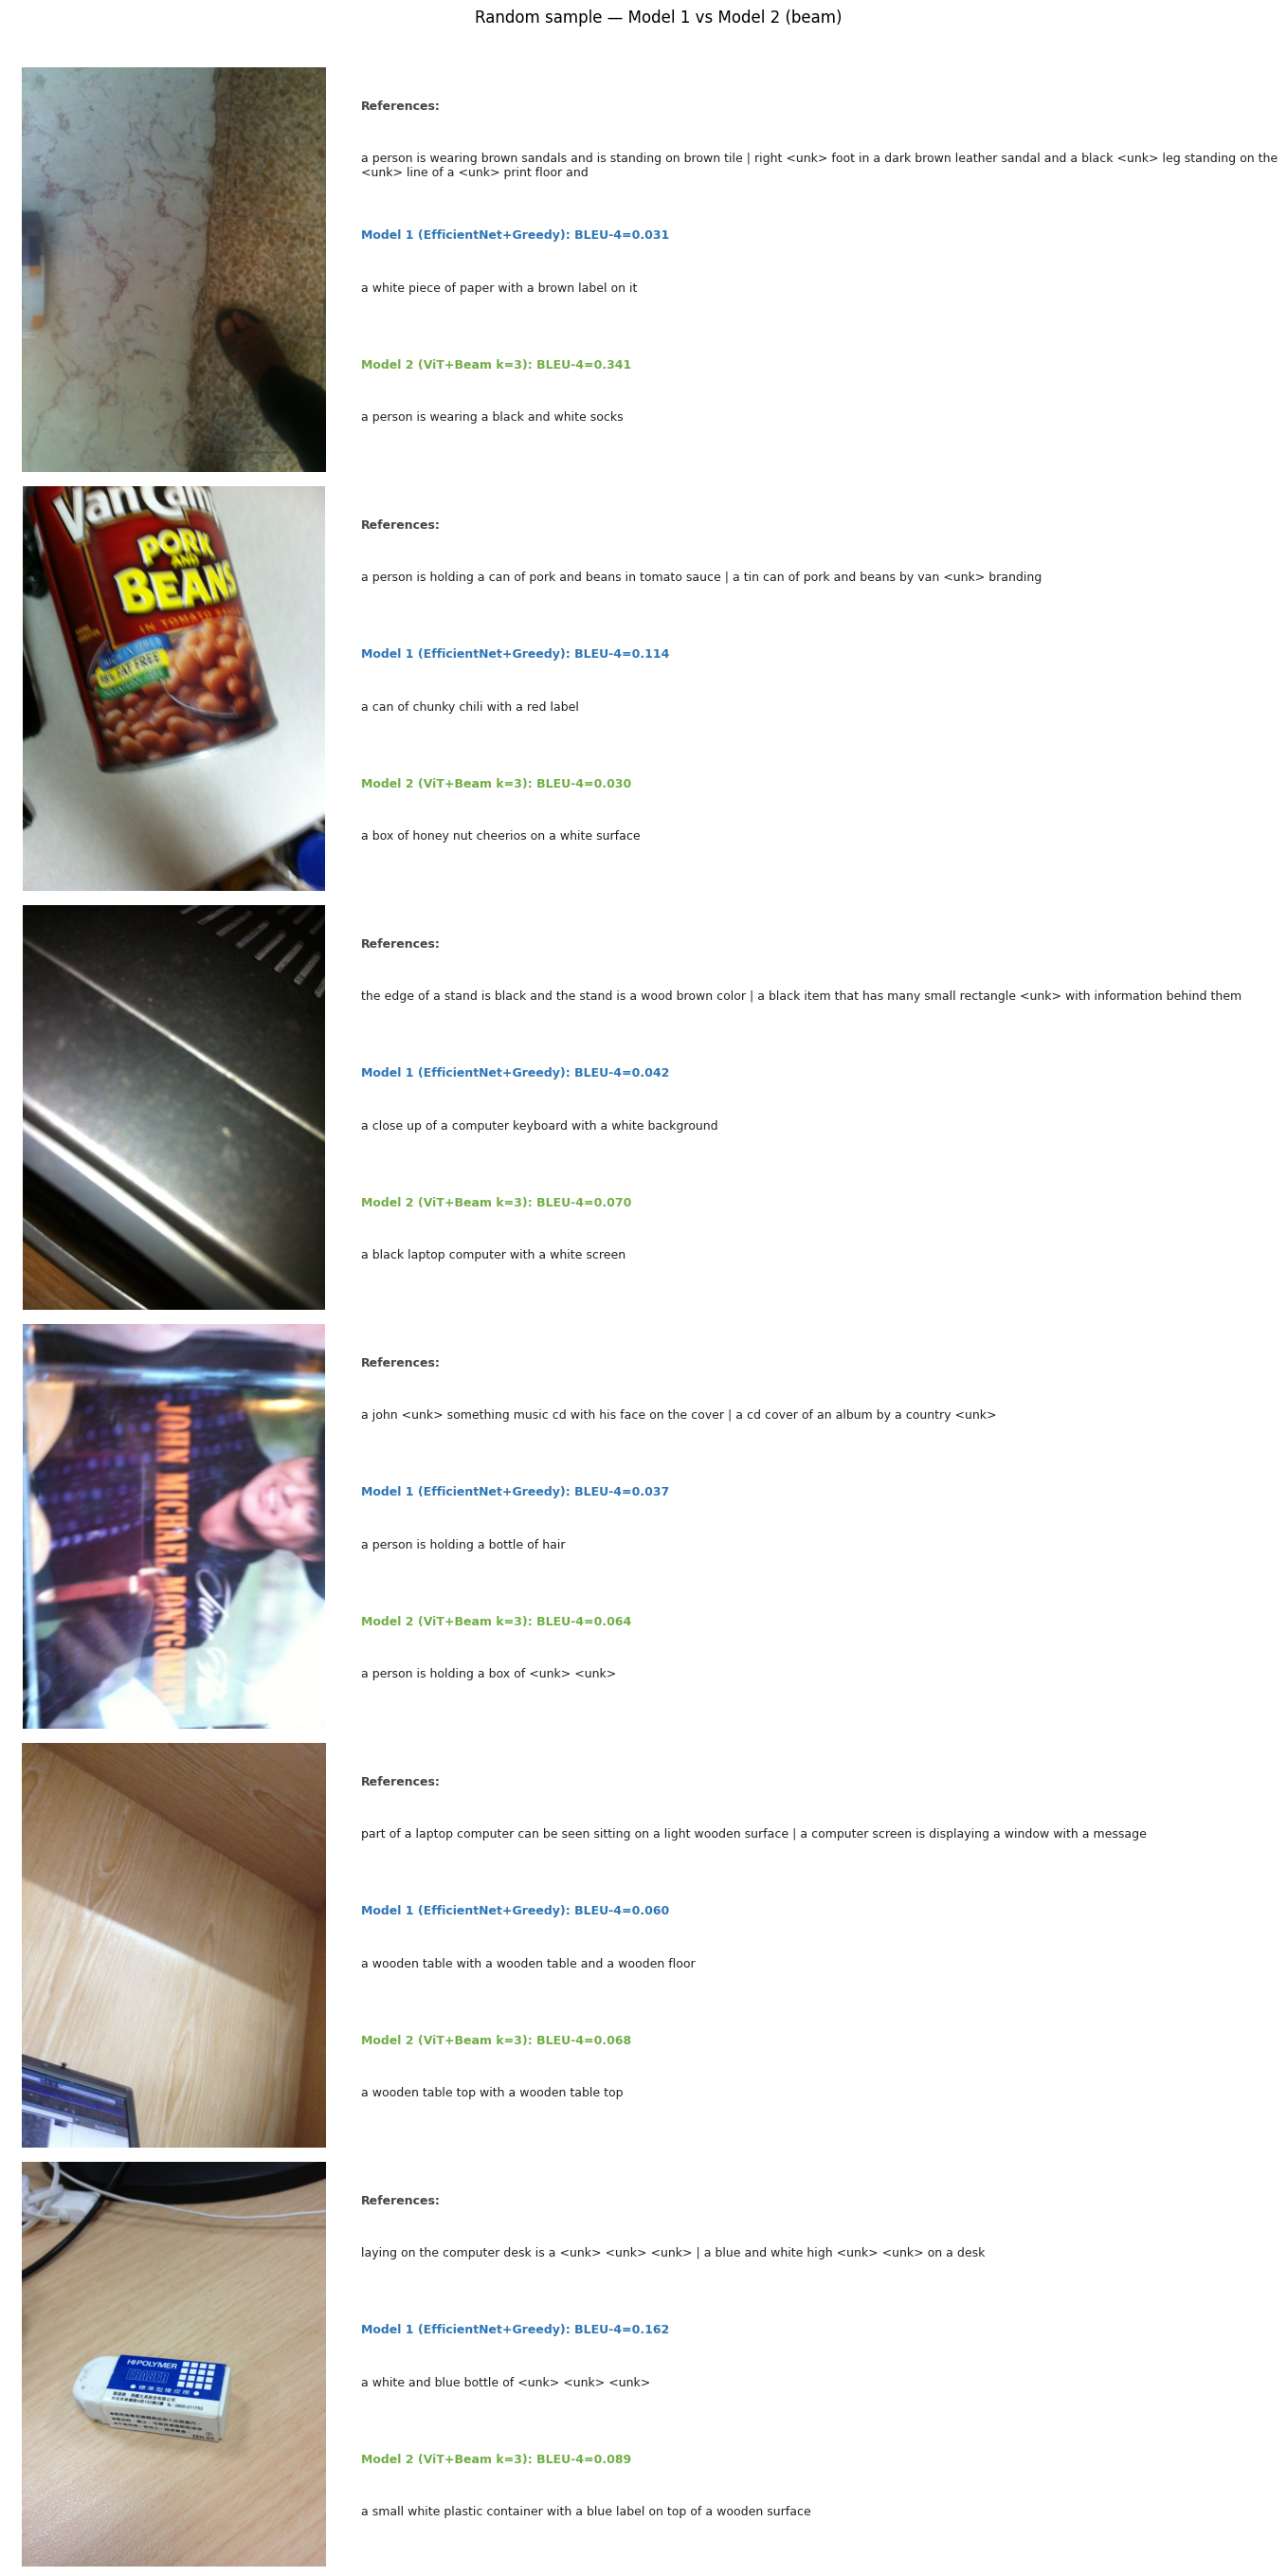

In [14]:
def show_side_by_side(items_df, n=6, title="Sample captions"):
    picks = items_df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n))
    if n == 1: axes = [axes]
    for ax, (_, row) in zip(axes, picks.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        # image on left
        ax_img = ax.inset_axes([0, 0, 0.28, 1])
        ax_img.imshow(img); ax_img.axis("off")
        ax.axis("off")
        lines = [
            ("References:", row["refs"], "#444444"),
            ("Model 1 (EfficientNet+Greedy):", row["m1_cap"],  f"BLEU-4={row['m1_bleu4']:.3f}", "#2E75B6"),
            ("Model 2 (ViT+Beam k=3):",        row["m2b_cap"], f"BLEU-4={row['m2b_bleu4']:.3f}", "#70AD47"),
        ]
        y = 0.92
        for item in lines:
            if len(item) == 3:
                label, text, color = item
                ax.text(0.30, y, label, transform=ax.transAxes,
                        fontsize=9, fontweight="bold", color=color, va="top")
                ax.text(0.30, y - 0.13, text, transform=ax.transAxes,
                        fontsize=9, color="#222222", va="top", wrap=True)
                y -= 0.32
            else:
                label, text, score, color = item
                ax.text(0.30, y, f"{label} {score}", transform=ax.transAxes,
                        fontsize=9, fontweight="bold", color=color, va="top")
                ax.text(0.30, y - 0.13, text, transform=ax.transAxes,
                        fontsize=9, color="#222222", va="top", wrap=True)
                y -= 0.32
    fig.suptitle(title, fontsize=12, y=1.005)
    plt.tight_layout(); plt.show()

show_side_by_side(scored, n=6, title="Random sample — Model 1 vs Model 2 (beam)")


### 6b. Cases where Model 2 most improves over Model 1

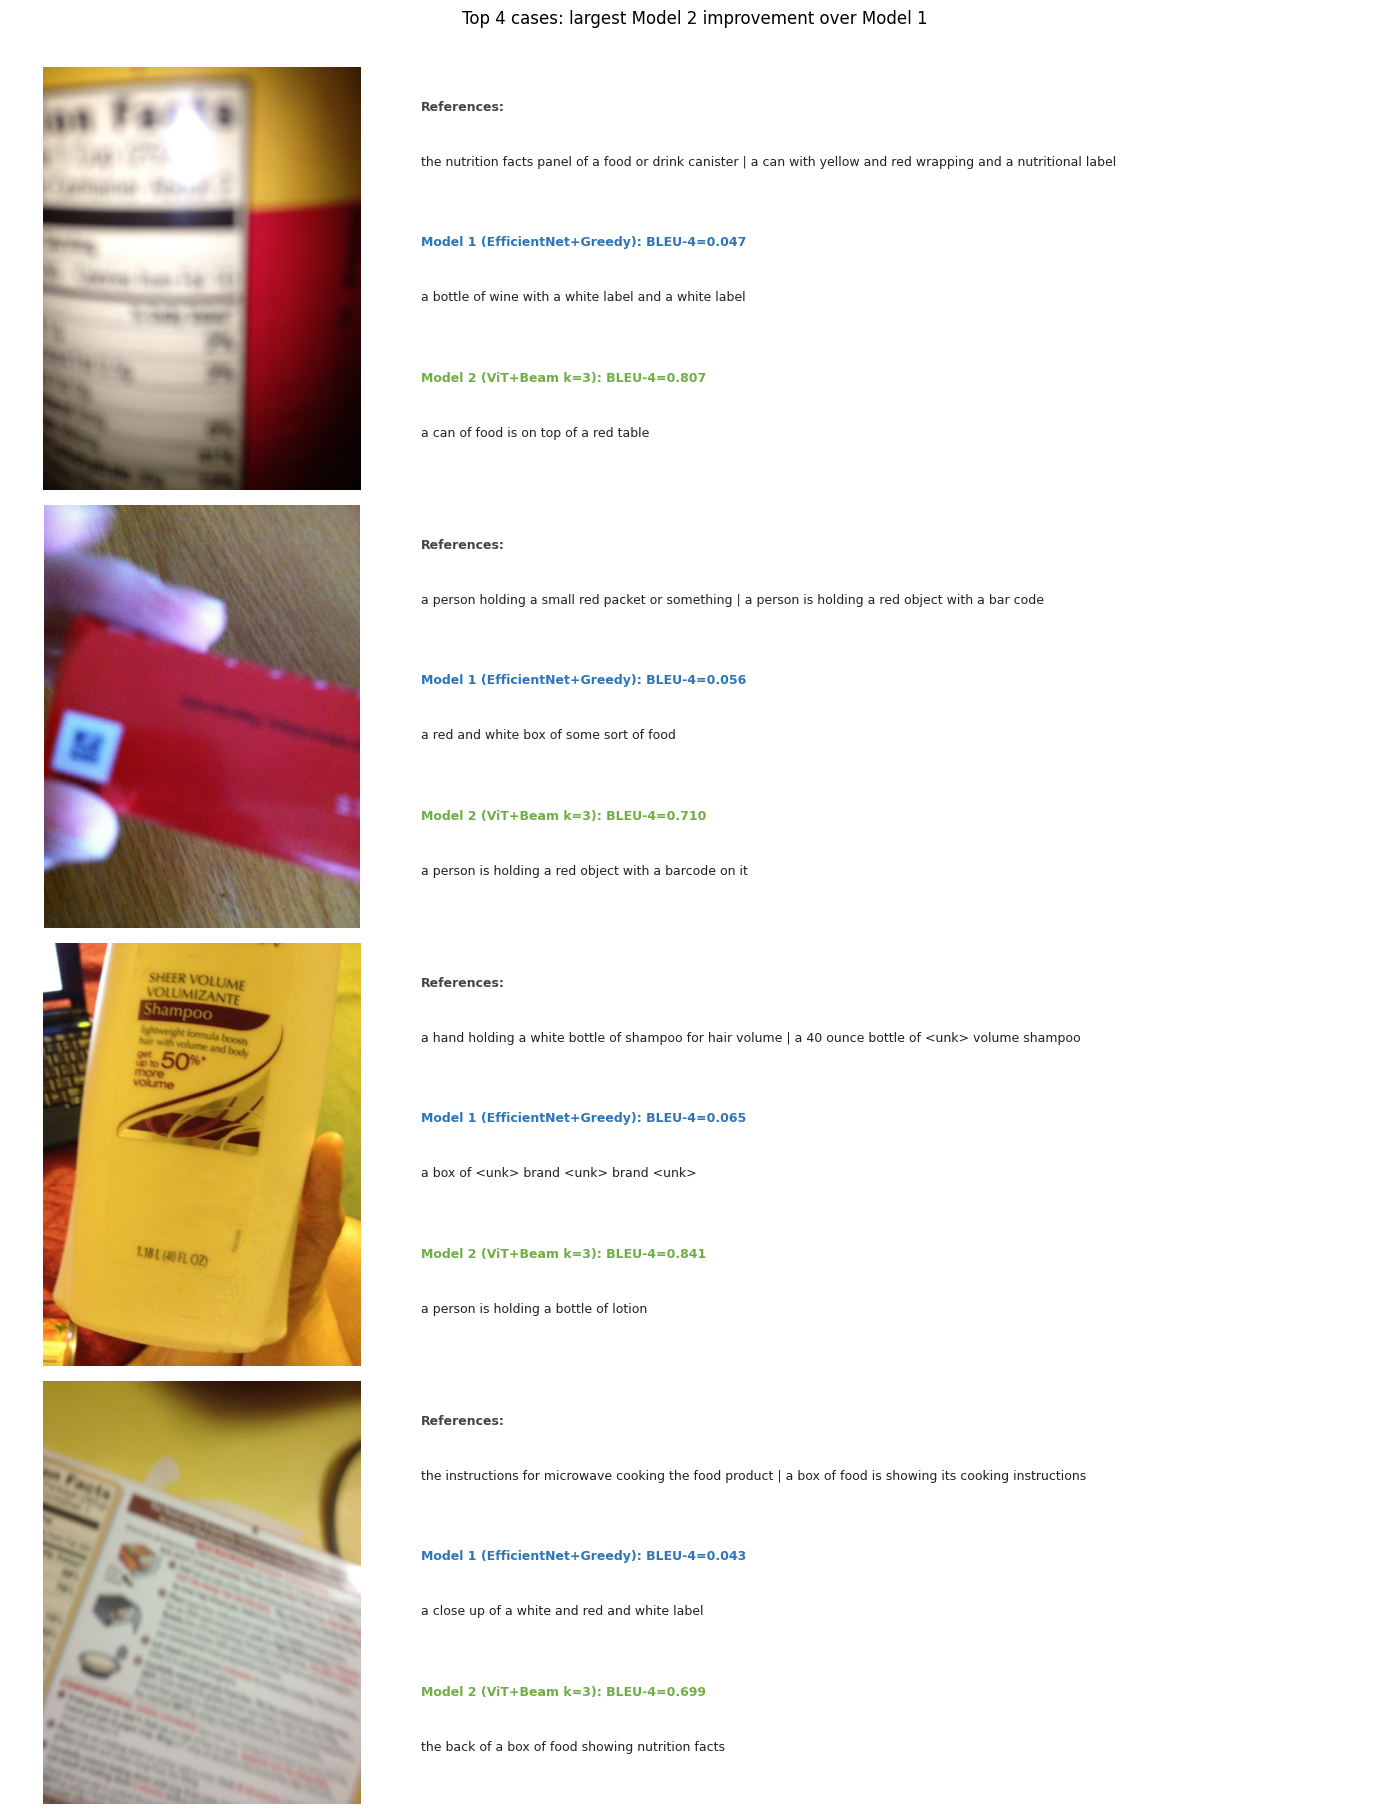

In [15]:
best_improvements = scored.nlargest(4, "m2b_vs_m1")
show_side_by_side(best_improvements, n=4,
                  title="Top 4 cases: largest Model 2 improvement over Model 1")


### 6c. Cases where both models struggle (lowest Model 2 beam BLEU-4)

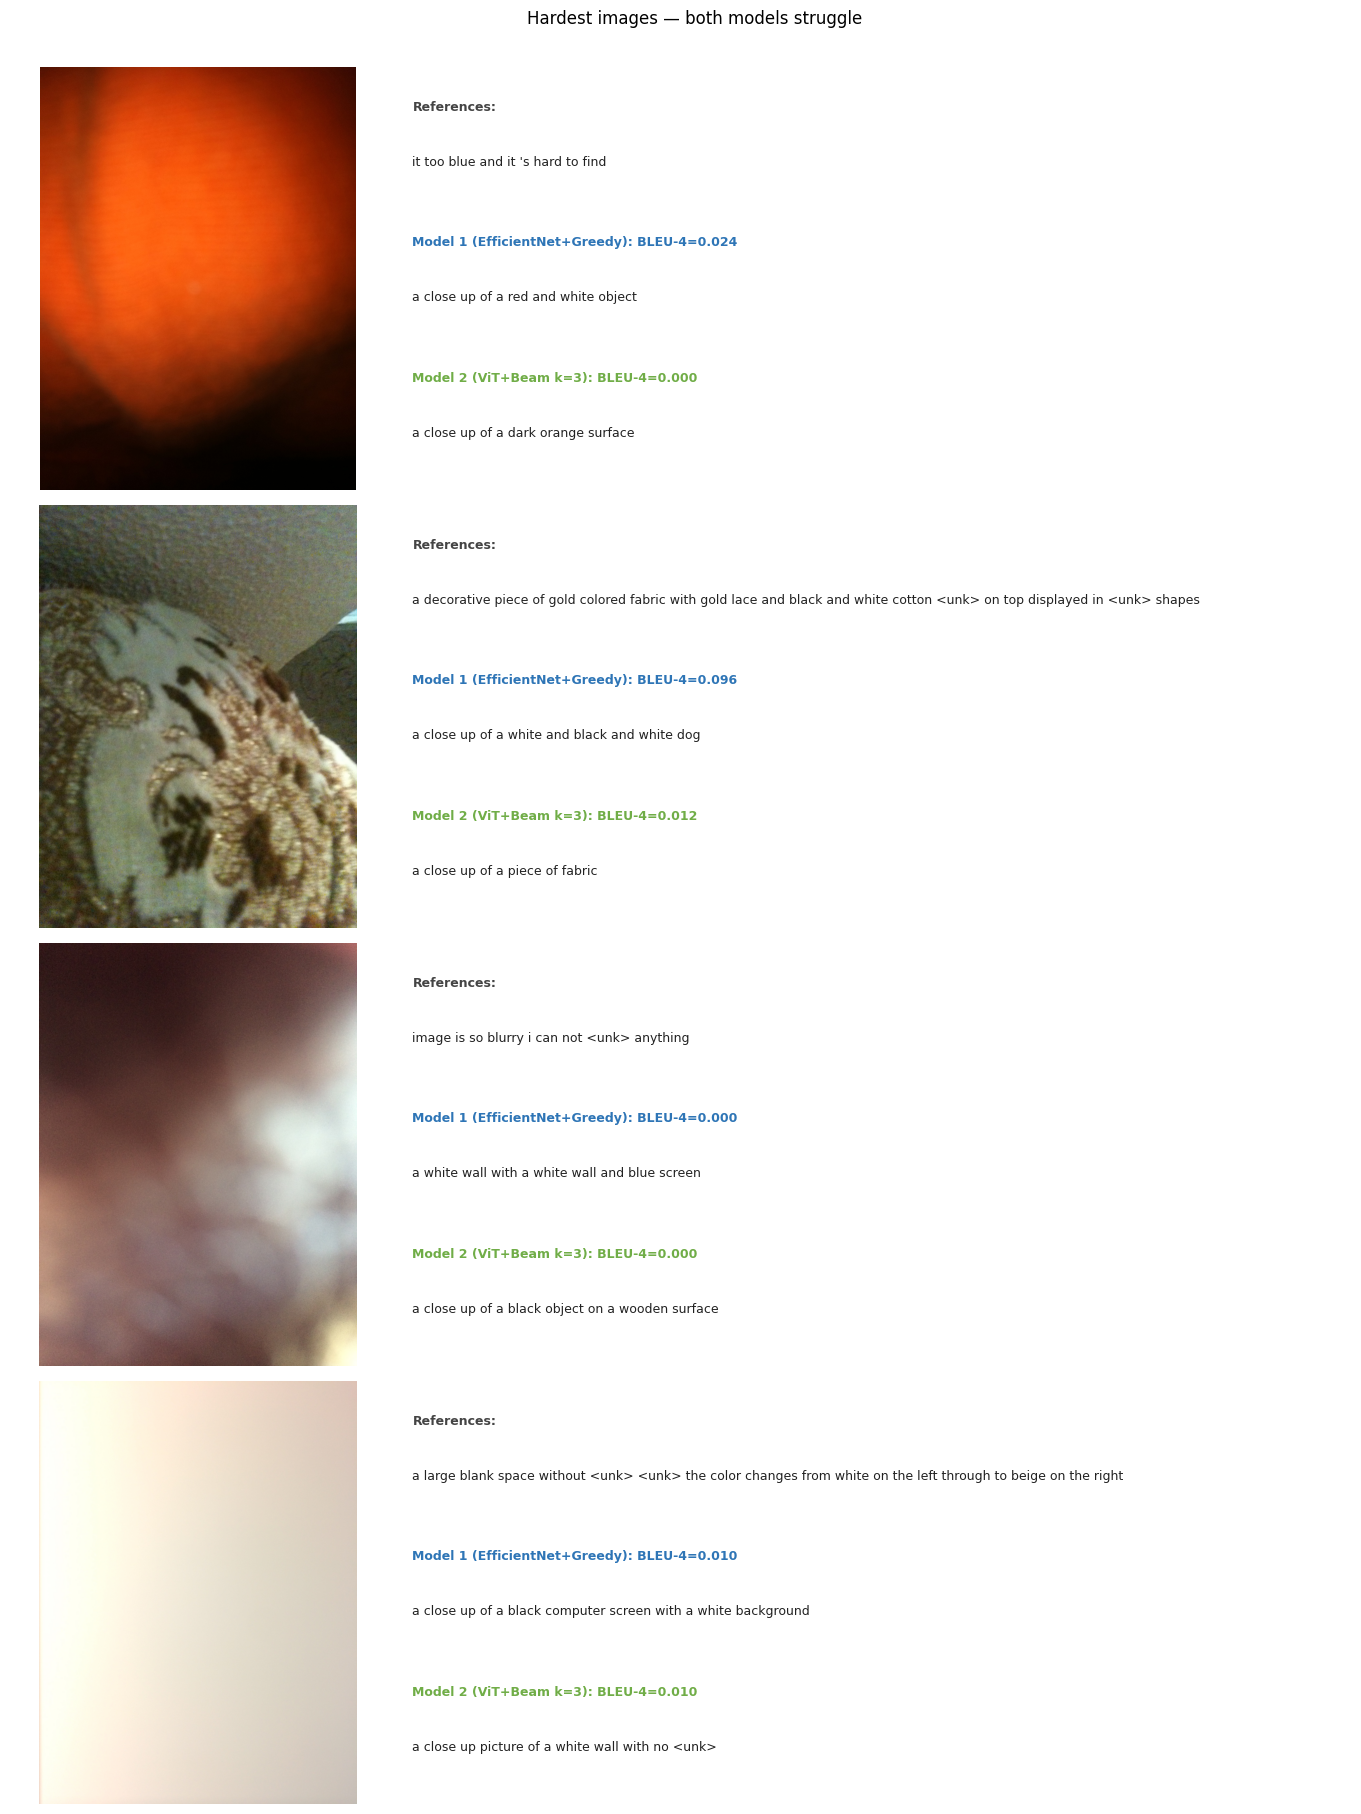

In [16]:
hardest = scored.nsmallest(4, "m2b_bleu4")
show_side_by_side(hardest, n=4,
                  title="Hardest images — both models struggle")


## 7. Error analysis

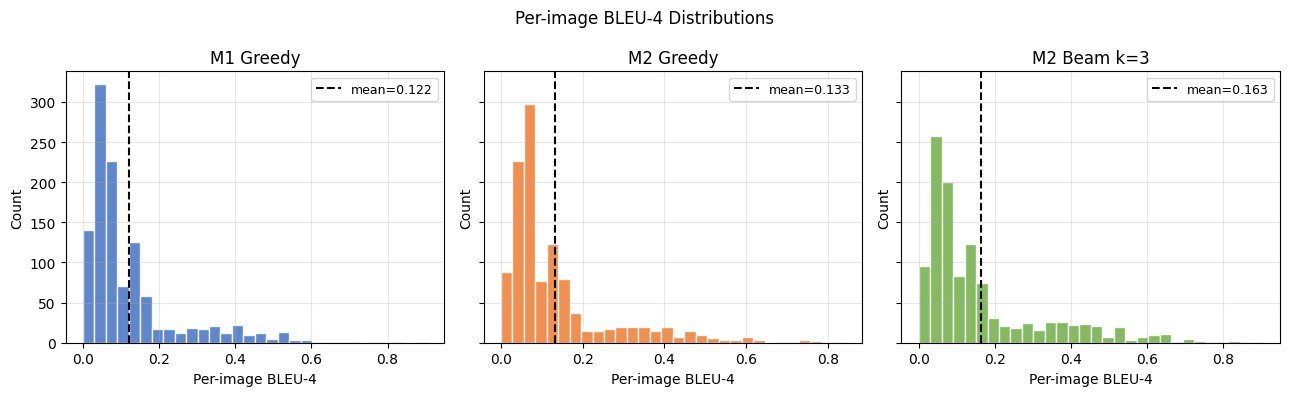

In [17]:
# Distribution of per-image BLEU-4
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col, label, color in zip(
    axes,
    ["m1_bleu4", "m2g_bleu4", "m2b_bleu4"],
    ["M1 Greedy", "M2 Greedy", "M2 Beam k=3"],
    ["#4472C4", "#ED7D31", "#70AD47"]
):
    ax.hist(scored[col], bins=30, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(scored[col].mean(), color="black", linestyle="--", lw=1.5,
               label=f"mean={scored[col].mean():.3f}")
    ax.set_xlabel("Per-image BLEU-4"); ax.set_ylabel("Count"); ax.set_title(label)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle("Per-image BLEU-4 Distributions", fontsize=12)
plt.tight_layout(); plt.show()


Per-image win/loss analysis (Model 1 greedy vs Model 2 beam):
  Model 1 wins :  439 / 1132  (38.8%)
  Model 2 wins :  656 / 1132  (58.0%)
  Ties         :   37 / 1132  (3.3%)


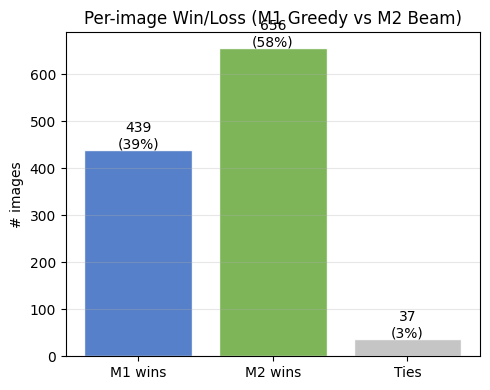

In [18]:
# Win/loss/tie matrix: how often does each model beat the other?
m1_wins  = (scored["m1_bleu4"] > scored["m2b_bleu4"]).sum()
m2_wins  = (scored["m2b_bleu4"] > scored["m1_bleu4"]).sum()
ties     = (scored["m1_bleu4"] == scored["m2b_bleu4"]).sum()
total    = len(scored)

print("Per-image win/loss analysis (Model 1 greedy vs Model 2 beam):")
print(f"  Model 1 wins : {m1_wins:4d} / {total}  ({m1_wins/total*100:.1f}%)")
print(f"  Model 2 wins : {m2_wins:4d} / {total}  ({m2_wins/total*100:.1f}%)")
print(f"  Ties         : {ties:4d} / {total}  ({ties/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["M1 wins", "M2 wins", "Ties"], [m1_wins, m2_wins, ties],
       color=["#4472C4", "#70AD47", "#BFBFBF"], edgecolor="white", alpha=0.9)
for i, v in enumerate([m1_wins, m2_wins, ties]):
    ax.text(i, v + 3, f"{v}\n({v/total*100:.0f}%)", ha="center", fontsize=10)
ax.set_ylabel("# images"); ax.set_title("Per-image Win/Loss (M1 Greedy vs M2 Beam)")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()


Average generated caption length:
  Model 1 greedy : 10.3 words
  Model 2 beam   : 10.4 words


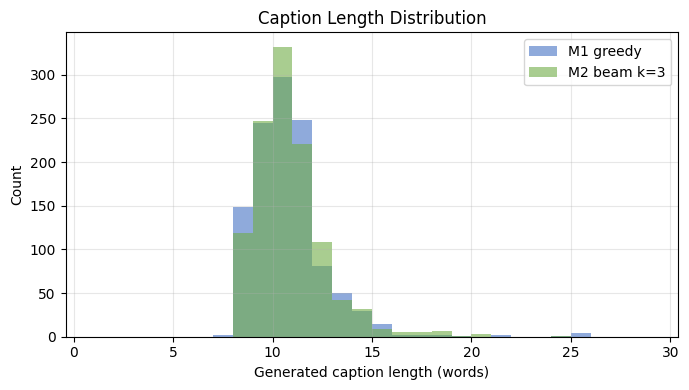

In [19]:
# Caption length analysis
scored["m1_len"]  = scored["m1_cap"].str.split().str.len()
scored["m2b_len"] = scored["m2b_cap"].str.split().str.len()

print("Average generated caption length:")
print(f"  Model 1 greedy : {scored['m1_len'].mean():.1f} words")
print(f"  Model 2 beam   : {scored['m2b_len'].mean():.1f} words")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scored["m1_len"],  bins=range(1, 30), alpha=0.6, label="M1 greedy",  color="#4472C4")
ax.hist(scored["m2b_len"], bins=range(1, 30), alpha=0.6, label="M2 beam k=3",color="#70AD47")
ax.set_xlabel("Generated caption length (words)")
ax.set_ylabel("Count"); ax.set_title("Caption Length Distribution")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 8. Full summary table

In [20]:
summary = pd.DataFrame({
    "": ["Architecture", "Encoder", "Decoder", "Decoding", "Memory tokens",
         "Trainable params", "Frozen params", "Best val loss", "Converged (epoch)",
         "Val BLEU-1", "Val BLEU-2", "Val BLEU-3", "Val BLEU-4",
         "Test BLEU-1", "Test BLEU-2", "Test BLEU-3", "Test BLEU-4"],
    "Model 1": [
        "EfficientNet-B0 + Transformer", "EfficientNet-B0 (frozen)", "Transformer (3L, 8H)",
        "Greedy", "49 (7×7)",
        f"{r1['trainable_params']:,}", f"{sum(p.numel() for p in model1.parameters()) - r1['trainable_params']:,}",
        f"{r1['best_val_loss']:.4f}", ckpt1['epoch'],
        f"{r1['val_bleu']['BLEU-1']:.4f}", f"{r1['val_bleu']['BLEU-2']:.4f}",
        f"{r1['val_bleu']['BLEU-3']:.4f}", f"{r1['val_bleu']['BLEU-4']:.4f}",
        f"{r1['test_bleu']['BLEU-1']:.4f}", f"{r1['test_bleu']['BLEU-2']:.4f}",
        f"{r1['test_bleu']['BLEU-3']:.4f}", f"{r1['test_bleu']['BLEU-4']:.4f}",
    ],
    "Model 2 (beam=3)": [
        "ViT-B/16 + Transformer + Beam", "ViT-B/16 (frozen)", "Transformer (3L, 8H)",
        "Beam search k=3", "196 (14×14)",
        f"{r2['trainable_params']:,}", f"{sum(p.numel() for p in model2.parameters()) - r2['trainable_params']:,}",
        f"{r2['best_val_loss']:.4f}", ckpt2['epoch'],
        f"{r2['val_bleu_beam']['BLEU-1']:.4f}", f"{r2['val_bleu_beam']['BLEU-2']:.4f}",
        f"{r2['val_bleu_beam']['BLEU-3']:.4f}", f"{r2['val_bleu_beam']['BLEU-4']:.4f}",
        f"{r2['test_bleu_beam']['BLEU-1']:.4f}", f"{r2['test_bleu_beam']['BLEU-2']:.4f}",
        f"{r2['test_bleu_beam']['BLEU-3']:.4f}", f"{r2['test_bleu_beam']['BLEU-4']:.4f}",
    ],
})
print(summary.to_string(index=False))


                                        Model 1              Model 2 (beam=3)
     Architecture EfficientNet-B0 + Transformer ViT-B/16 + Transformer + Beam
          Encoder      EfficientNet-B0 (frozen)             ViT-B/16 (frozen)
          Decoder          Transformer (3L, 8H)          Transformer (3L, 8H)
         Decoding                        Greedy               Beam search k=3
    Memory tokens                      49 (7×7)                   196 (14×14)
 Trainable params                     5,145,230                     5,014,158
    Frozen params                     4,007,548                    85,798,656
    Best val loss                        4.0374                        3.9819
Converged (epoch)                            11                            12
       Val BLEU-1                        0.5589                        0.6120
       Val BLEU-2                        0.3619                        0.4195
       Val BLEU-3                        0.2280                 